Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [1]:
# Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load the movies dataset
automobiles_df = pd.read_csv('automobile.txt')
automobiles_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [3]:
# Drop normalized-losses and symboling columns
automobiles_df.drop(["normalized-losses", "symboling"], axis=1, inplace=True)   

#### Remove any duplicate rows

In [4]:
# Drop duplicate rows
automobiles_df.drop_duplicates()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [5]:
# Drop rows with missing values by replacing '?' with NaN and then dropping those rows
automobiles_df.replace('?', np.nan, inplace=True)
automobiles_df.dropna(inplace=True)

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [6]:
# Identify columns with float64 data type and convert them to int64
floats = automobiles_df.select_dtypes('float64').columns
automobiles_df[floats] = automobiles_df[floats].astype('int64')


col = automobiles_df.select_dtypes('str').columns
for columns in col:
    try:
        automobiles_df[columns] = pd.to_numeric(automobiles_df[columns].astype('Int64'))
    except ValueError:
        pass

automobiles_df.info()


<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   make               193 non-null    str  
 1   fuel-type          193 non-null    str  
 2   aspiration         193 non-null    str  
 3   num-of-doors       193 non-null    str  
 4   body-style         193 non-null    str  
 5   drive-wheels       193 non-null    str  
 6   engine-location    193 non-null    str  
 7   wheel-base         193 non-null    int64
 8   length             193 non-null    int64
 9   width              193 non-null    int64
 10  height             193 non-null    int64
 11  curb-weight        193 non-null    int64
 12  engine-type        193 non-null    str  
 13  num-of-cylinders   193 non-null    str  
 14  engine-size        193 non-null    int64
 15  fuel-system        193 non-null    str  
 16  bore               193 non-null    str  
 17  stroke             193 non-null 

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [7]:
# Create a dataframe with all the cars in the "hatchback' category
hatchback_cars = automobiles_df[automobiles_df['body-style'] == 'hatchback']
print(hatchback_cars)

            make fuel-type aspiration num-of-doors body-style drive-wheels  \
2    alfa-romero       gas        std          two  hatchback          rwd   
18     chevrolet       gas        std          two  hatchback          fwd   
19     chevrolet       gas        std          two  hatchback          fwd   
21         dodge       gas        std          two  hatchback          fwd   
22         dodge       gas        std          two  hatchback          fwd   
..           ...       ...        ...          ...        ...          ...   
175       toyota       gas        std         four  hatchback          fwd   
177       toyota       gas        std         four  hatchback          fwd   
178       toyota       gas        std          two  hatchback          rwd   
179       toyota       gas        std          two  hatchback          rwd   
190   volkswagen       gas        std          two  hatchback          fwd   

    engine-location  wheel-base  length  width  ...  engine-siz

### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

Answer: The 5 most expensive cars are hardtop mercedes-benz, sedan 2 door bmw, sedan mercedez-benz, convertible porsche, and a 4 door bmw.
The comparison between the most expensive and cheapest cars range between $35000 to $40000. The mpg on the most expensive cars are one of the least ranges compared to the cheapest cars.

In [8]:
# Identify the 5 most expensive cars in the dataset
most_expensive_cars = automobiles_df.nlargest(5, 'price')
print(most_expensive_cars)


              make fuel-type aspiration num-of-doors   body-style  \
74   mercedes-benz       gas        std          two      hardtop   
16             bmw       gas        std          two        sedan   
73   mercedes-benz       gas        std         four        sedan   
128        porsche       gas        std          two  convertible   
17             bmw       gas        std         four        sedan   

    drive-wheels engine-location  wheel-base  length  width  ...  engine-size  \
74           rwd           front         112     199     72  ...          304   
16           rwd           front         103     193     67  ...          209   
73           rwd           front         120     208     71  ...          308   
128          rwd            rear          89     168     65  ...          194   
17           rwd           front         110     197     70  ...          209   

     fuel-system  bore stroke  compression-ratio horsepower peak-rpm city-mpg  \
74          mpfi 

In [9]:
least_expensive_cars = automobiles_df.nsmallest(5, 'price')
print(least_expensive_cars)

           make fuel-type aspiration num-of-doors body-style drive-wheels  \
138      subaru       gas        std          two  hatchback          fwd   
18    chevrolet       gas        std          two  hatchback          fwd   
50        mazda       gas        std          two  hatchback          fwd   
150      toyota       gas        std          two  hatchback          fwd   
76   mitsubishi       gas        std          two  hatchback          fwd   

    engine-location  wheel-base  length  width  ...  engine-size  fuel-system  \
138           front          93     156     63  ...           97         2bbl   
18            front          88     141     60  ...           61         2bbl   
50            front          93     159     64  ...           91         2bbl   
150           front          95     158     63  ...           92         2bbl   
76            front          93     157     64  ...           92         2bbl   

     bore stroke  compression-ratio horsepower pea

#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

Answer: The manufacturer that buils the most fuel efficient vehicle in both city and highway mpg is Chevrolet

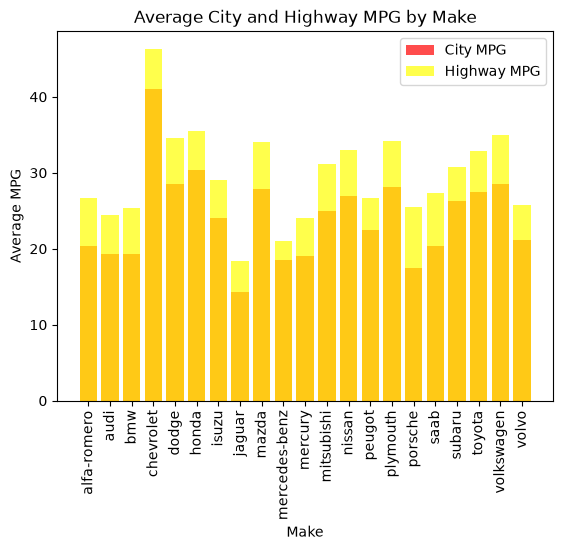

In [10]:
# Identify the manufacturers with the highest average city and highway mpg

mean_city_mpg = automobiles_df.groupby('make')['city-mpg'].mean()
mean_hwy_mpg = automobiles_df.groupby('make')['highway-mpg'].mean()

figure, axis = plt.subplots()
bars = axis.bar(mean_city_mpg.index, mean_city_mpg.values, label='City MPG', color='red', alpha=0.7)
axis.bar(mean_hwy_mpg.index, mean_hwy_mpg.values, label='Highway MPG', color='yellow', alpha=0.7)
axis.set_xlabel('Make')
axis.set_ylabel('Average MPG')
axis.set_title('Average City and Highway MPG by Make')
axis.xaxis.set_tick_params(rotation=90)
axis.legend()

plt.show()



#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

Answer: The vehicles with the largest engine capacity are jaguars and mercedes-benz.

In [11]:
# Sort the top 5 cars with the largest engine size
automobiles_df.sort_values(by = 'engine-size', ascending = False)


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
49,jaguar,gas,std,two,sedan,rwd,front,102,191,70,...,326,mpfi,3.54,2.76,11,262,5000,13,17,36000
73,mercedes-benz,gas,std,four,sedan,rwd,front,120,208,71,...,308,mpfi,3.80,3.35,8,184,4500,14,16,40960
74,mercedes-benz,gas,std,two,hardtop,rwd,front,112,199,72,...,304,mpfi,3.80,3.35,8,184,4500,14,16,45400
47,jaguar,gas,std,four,sedan,rwd,front,113,199,69,...,258,mpfi,3.63,4.17,8,176,4750,15,19,32250
48,jaguar,gas,std,four,sedan,rwd,front,113,199,69,...,258,mpfi,3.63,4.17,8,176,4750,15,19,35550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,dodge,gas,std,four,sedan,fwd,front,93,157,63,...,90,2bbl,2.97,3.23,9,68,5500,31,38,6692
121,plymouth,gas,std,four,sedan,fwd,front,93,167,63,...,90,2bbl,2.97,3.23,9,68,5500,31,38,6692
118,plymouth,gas,std,two,hatchback,fwd,front,93,157,63,...,90,2bbl,2.97,3.23,9,68,5500,37,41,5572
32,honda,gas,std,two,hatchback,fwd,front,93,150,64,...,79,1bbl,2.91,3.07,10,60,5500,38,42,5399


#### Which vehicle manufacturer has the most car models in the dataset

Answer: The manufacturer with the most car models in the dataset is Toyota with 32 cars.

In [12]:
# Identify the most common car models in the dataset
most_common_models = automobiles_df['make'].value_counts().head(5)
print(most_common_models)




make
toyota        32
nissan        18
honda         13
mitsubishi    13
mazda         12
Name: count, dtype: int64
